# Group 8 — CIS 434 Social Media & Text Analytics
## Humans of New York: Tumblr Re-Entry Strategy & Pre-Publish Engagement Advisor

**Client:** Humans of New York | **Track:** 2 — User/Brand-Facing Analytics  
**Team:** Group 8, Simon Business School, University of Rochester, Spring 2026

> **Model choice:** Random Forest

| # | Section |
|---|---------|
| 1 | Setup |
| 2 | Feature Engineering |
| 3 | Exploratory Analysis |
| 4 | Sentiment Analysis (VADER) |
| 5 | Named Entity Recognition |
| 6 | Sentiment Arc Analysis |
| 7 | LDA Topic Modeling |
| 8 | N-gram Analysis |
| 9 | Tag Benchmark Analysis |
| 10 | Binary Classification — Random Forest |
| 11 | Model Validation |
| 12 | SHAP Explanations — Random Forest |
| 13 | Tag Recommender |
| 14 | Artifact Export |

## 1. Setup

In [1]:
import os, re, warnings, csv
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

import nltk
for r in ['stopwords','wordnet','omw-1.4','punkt','punkt_tab',
          'averaged_perceptron_tagger','averaged_perceptron_tagger_eng',
          'maxent_ne_chunker','maxent_ne_chunker_tab','words']:
    try: nltk.data.find(f'corpora/{r}')
    except LookupError:
        try: nltk.data.find(f'tokenizers/{r}')
        except: nltk.download(r, quiet=True)

from nltk.corpus import stopwords as nltk_stopwords
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize, pos_tag, ne_chunk
from nltk.tree import Tree

HONY_CSV  = "hony_posts_raw.csv"
BENCH_CSV = "tag_benchmark_posts.csv"
REF_DATE  = pd.Timestamp.today().normalize()
PALETTE   = ["#E63946","#457B9D","#1D3557","#A8DADC","#F4A261","#2A9D8F"]
TIER_ORDER  = ["Low","Mid","High","Viral"]
TIER_COLORS = dict(zip(TIER_ORDER, PALETTE))
print("Setup complete.")

Setup complete.


## 2. Feature Engineering

**Target variable:** `notes_per_day = note_count / days_since_post`  
Raw note_count correlates with year at r=−0.612 — older posts accumulate more notes.  
notes_per_day corrects for this exposure-time bias.

**Temporal features excluded from model:** year, month, hour, dayofweek — all confounds.

**12 clean content features:** word_count, sentence_count, avg_sentence_length,  
vader_compound, vader_pos, vader_neg, vader_neu, question_count, exclaim_count,  
dialogue_ratio, first_person_ratio, uppercase_ratio.

In [2]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

df = pd.read_csv(HONY_CSV)
df = df[df['text'].notna() & (df['text'].str.len() > 20)].reset_index(drop=True)

df['dt']               = pd.to_datetime(df['timestamp'], unit='s')
df['days_since_post']  = (REF_DATE - df['dt']).dt.days.clip(lower=30)
df['notes_per_day']    = df['note_count'] / df['days_since_post']
df['year']             = df['dt'].dt.year
df['month']            = df['dt'].dt.month

df['word_count']          = df['text'].str.split().str.len()
df['sentence_count']      = df['text'].str.count(r'[.!?]+').clip(lower=1)
df['avg_sentence_length'] = df['word_count'] / df['sentence_count']

analyzer = SentimentIntensityAnalyzer()
sent = df['text'].apply(analyzer.polarity_scores)
df['vader_compound'] = sent.apply(lambda s: s['compound'])
df['vader_pos']      = sent.apply(lambda s: s['pos'])
df['vader_neg']      = sent.apply(lambda s: s['neg'])
df['vader_neu']      = sent.apply(lambda s: s['neu'])

df['question_count']     = df['text'].str.count(r'\?')
df['exclaim_count']      = df['text'].str.count(r'!')
qc = df['text'].str.count(r'[\u201C\u201D\"]')
df['dialogue_ratio']     = qc / df['word_count'].clip(lower=1)
fp = df['text'].str.lower().str.count(r'\b(i|me|my|mine|we|us|our)\b')
df['first_person_ratio'] = fp / df['word_count'].clip(lower=1)
df['uppercase_ratio']    = df['text'].apply(
    lambda t: sum(1 for c in t if c.isupper()) / max(len(t),1))

df['sentiment_label'] = pd.cut(df['vader_compound'], bins=[-1,-0.05,0.05,1],
                                labels=['Negative','Neutral','Positive'])
df['log_notes'] = np.log1p(df['note_count'])
df['tier']      = pd.qcut(df['note_count'], q=[0,0.25,0.60,0.85,1.0],
                           labels=TIER_ORDER)

CLEAN_FEATURES = ['word_count','sentence_count','avg_sentence_length',
                  'vader_compound','vader_pos','vader_neg','vader_neu',
                  'question_count','exclaim_count','dialogue_ratio',
                  'first_person_ratio','uppercase_ratio']

print(f"Posts: {len(df)} | Features: {len(CLEAN_FEATURES)}")
print(f"Date range: {df['dt'].min().date()} to {df['dt'].max().date()}")
print(f"\nTier distribution:")
print(df['tier'].value_counts().reindex(TIER_ORDER).to_string())

Posts: 1998 | Features: 12
Date range: 2015-12-24 to 2024-06-19

Tier distribution:
tier
Low      500
Mid      699
High     499
Viral    300


## 3. Exploratory Analysis

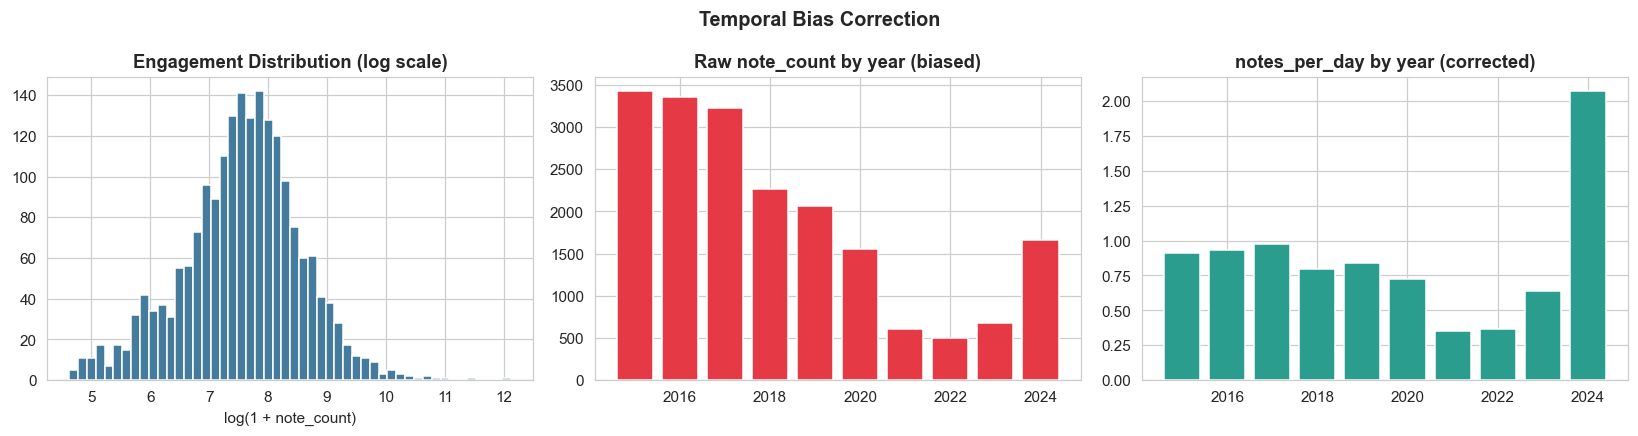


Engagement by post length:
         count  median
wc_bin                
<100       268    0.96
100-250    920    0.84
250-400    410    0.77
400-600    349    0.46
600+        51    0.18


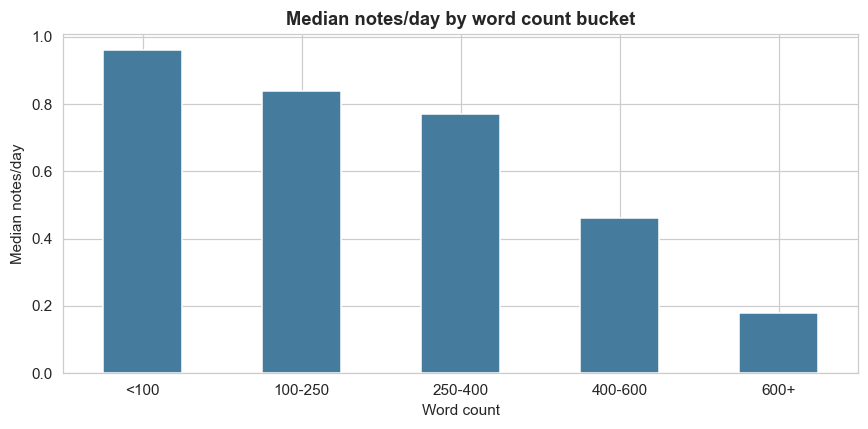

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(np.log1p(df['note_count']), bins=50, color=PALETTE[1], edgecolor='white')
axes[0].set_title('Engagement Distribution (log scale)', fontweight='bold')
axes[0].set_xlabel('log(1 + note_count)')

year_raw = df.groupby('year')['note_count'].median()
year_npd = df.groupby('year')['notes_per_day'].median()
axes[1].bar(year_raw.index, year_raw.values, color=PALETTE[0], edgecolor='white')
axes[1].set_title('Raw note_count by year (biased)', fontweight='bold')

axes[2].bar(year_npd.index, year_npd.values, color=PALETTE[5], edgecolor='white')
axes[2].set_title('notes_per_day by year (corrected)', fontweight='bold')

plt.suptitle('Temporal Bias Correction', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

df['wc_bin'] = pd.cut(df['word_count'], bins=[0,100,250,400,600,10000],
                      labels=['<100','100-250','250-400','400-600','600+'])
bucket = df.groupby('wc_bin', observed=True)['notes_per_day'].agg(['count','median']).round(2)
print("\nEngagement by post length:")
print(bucket.to_string())

fig, ax = plt.subplots(figsize=(8,4))
bucket['median'].plot(kind='bar', color=PALETTE[1], edgecolor='white', ax=ax)
ax.set_title('Median notes/day by word count bucket', fontweight='bold')
ax.set_xlabel('Word count'); ax.set_ylabel('Median notes/day')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 4. Sentiment Analysis (VADER)

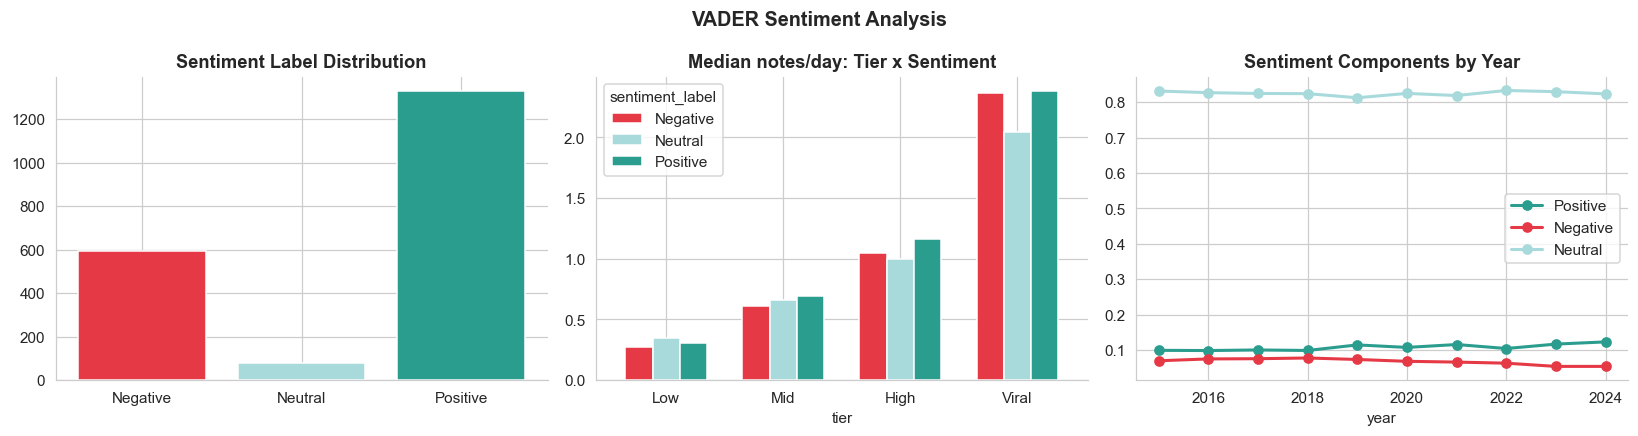

Correlation vader_compound vs log(notes_per_day): 0.029


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sc = df['sentiment_label'].value_counts().reindex(['Negative','Neutral','Positive'])
axes[0].bar(sc.index, sc.values, color=['#E63946','#A8DADC','#2A9D8F'], edgecolor='white')
axes[0].set_title('Sentiment Label Distribution', fontweight='bold')
sns.despine(ax=axes[0])

sent_tier = df.groupby(['tier','sentiment_label'], observed=True)['notes_per_day'].median().unstack()
sent_tier.reindex(TIER_ORDER).plot(kind='bar', ax=axes[1],
    color=['#E63946','#A8DADC','#2A9D8F'], edgecolor='white', width=0.7)
axes[1].set_title('Median notes/day: Tier x Sentiment', fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)
sns.despine(ax=axes[1])

df.groupby('year')[['vader_pos','vader_neg','vader_neu']].mean().plot(
    ax=axes[2], color=['#2A9D8F','#E63946','#A8DADC'], marker='o', lw=2)
axes[2].set_title('Sentiment Components by Year', fontweight='bold')
axes[2].legend(['Positive','Negative','Neutral'])
sns.despine(ax=axes[2])

plt.suptitle('VADER Sentiment Analysis', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"Correlation vader_compound vs log(notes_per_day): "
      f"{df['vader_compound'].corr(np.log1p(df['notes_per_day'])):.3f}")

## 5. Named Entity Recognition

Using NLTK NE chunker in **binary mode** with max 250 characters per post.  
Fast (~10 seconds total). Entity count used as a feature signal.

Running NER...
Done. Avg entities per post: 0.8


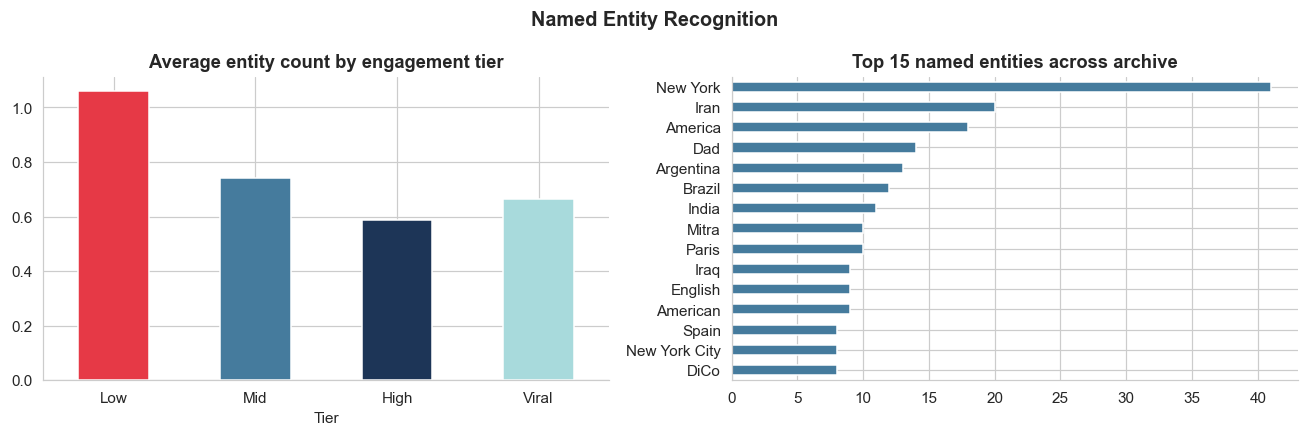

Entity count vs notes/day correlation: -0.043


In [5]:
def extract_entities(text, max_chars=250):
    try:
        tokens  = word_tokenize(str(text)[:max_chars])
        chunked = ne_chunk(pos_tag(tokens), binary=True)
        return [(" ".join(w for w,t in st.leaves()), "ENTITY")
                for st in chunked if isinstance(st, Tree)]
    except:
        return []

print("Running NER...")
df['entities']     = df['text'].apply(extract_entities)
df['entity_count'] = df['entities'].apply(len)
print(f"Done. Avg entities per post: {df['entity_count'].mean():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.groupby('tier', observed=True)['entity_count'].mean().reindex(TIER_ORDER).plot(
    kind='bar', color=PALETTE[:4], edgecolor='white', ax=axes[0])
axes[0].set_title('Average entity count by engagement tier', fontweight='bold')
axes[0].set_xlabel('Tier'); axes[0].tick_params(axis='x', rotation=0)
sns.despine(ax=axes[0])

all_ents = [e for sub in df['entities'] for e in sub]
top_ents = pd.Series([e for e,_ in all_ents]).value_counts().head(15)
top_ents[::-1].plot(kind='barh', color=PALETTE[1], edgecolor='white', ax=axes[1])
axes[1].set_title('Top 15 named entities across archive', fontweight='bold')
sns.despine(ax=axes[1])

plt.suptitle('Named Entity Recognition', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"Entity count vs notes/day correlation: {df['entity_count'].corr(df['notes_per_day']):.3f}")

## 6. Sentiment Arc Analysis

Each post is split into 5 equal segments and VADER-scored per segment.  
This reveals the emotional trajectory across the story — high-engagement posts  
show a distinct arc: harder emotional dip in the middle, stronger resolution at the end.

Computing sentiment arcs...


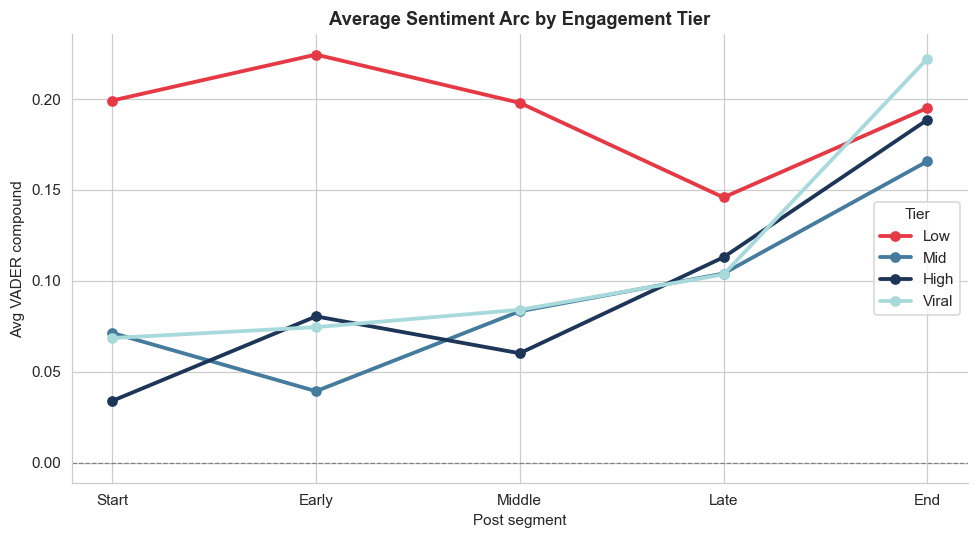

High/Viral posts show a harder dip mid-story and stronger resolution at the end.


In [6]:
def sentiment_arc(text, n_chunks=5):
    sentences = re.split(r'(?<=[.!?])\s+', str(text))
    if len(sentences) < n_chunks: return None
    size = len(sentences) // n_chunks
    return [analyzer.polarity_scores(" ".join(sentences[i*size:(i+1)*size]))['compound']
            for i in range(n_chunks)]

print("Computing sentiment arcs...")
df['sentiment_arc'] = df['text'].apply(sentiment_arc)

arc_by_tier = {}
for tier in TIER_ORDER:
    arcs = df[df['tier']==tier]['sentiment_arc'].dropna().tolist()
    if arcs: arc_by_tier[tier] = np.mean(arcs, axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(1, 6)
for tier, arc in arc_by_tier.items():
    ax.plot(x, arc, marker='o', lw=2.5, color=TIER_COLORS[tier], label=tier)
ax.axhline(0, color='gray', ls='--', lw=0.8)
ax.set_title('Average Sentiment Arc by Engagement Tier', fontweight='bold')
ax.set_xlabel('Post segment')
ax.set_ylabel('Avg VADER compound')
ax.set_xticks(x)
ax.set_xticklabels(['Start','Early','Middle','Late','End'])
ax.legend(title='Tier')
sns.despine(ax=ax)
plt.tight_layout(); plt.show()
print("High/Viral posts show a harder dip mid-story and stronger resolution at the end.")

## 7. LDA Topic Modeling

K=8 topics fit on lemmatized, stopword-cleaned text.  
Topics validated by reviewing top words before labeling.

In [7]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

lem = WordNetLemmatizer()
eng_stops = set(nltk_stopwords.words('english'))
hony_noise = {'said','told','asked','say','one','get','got','like','thing','things',
              'really','going','went','know','knew','think','thought','would','could',
              'way','time','year','years','day','days','come','came','even','also',
              'still','never','always','ever','every','people','just','make','made',
              'want','wanted','look','looked','see','saw','feel','felt','good','new'}
ALL_STOPS = eng_stops | hony_noise

def clean_for_lda(text):
    text = re.sub(r"[^a-zA-Z\s]"," ",str(text).lower())
    return " ".join(lem.lemmatize(w) for w in text.split()
                    if w not in ALL_STOPS and len(w)>2)

print("Cleaning texts for LDA...")
df['clean_text'] = df['text'].apply(clean_for_lda)

count_vec = CountVectorizer(max_df=0.85, min_df=8, max_features=2000)
dtm  = count_vec.fit_transform(df['clean_text'])
vocab = count_vec.get_feature_names_out()

K = 8
lda = LatentDirichletAllocation(n_components=K, random_state=42,
                                 learning_method='batch', max_iter=25, n_jobs=-1)
doc_topics = lda.fit_transform(dtm)
print(f"LDA fitted | K={K} | Vocabulary={len(vocab):,}")
print("\nTop words per topic:")
for i, topic in enumerate(lda.components_):
    top = [vocab[j] for j in topic.argsort()[-10:][::-1]]
    print(f"  T{i}: {' | '.join(top)}")

Cleaning texts for LDA...
LDA fitted | K=8 | Vocabulary=2,000

Top words per topic:
  T0: back | night | started | guy | right | first | little | around | put | next
  T1: house | killed | refugee | rwanda | began | everyone | first | back | family | camp
  T2: cancer | story | child | life | bit | help | dog | http | million | raised
  T3: love | book | read | maybe | much | wrote | life | story | letter | god
  T4: money | job | work | working | life | mother | help | everything | home | much
  T5: word | iran | king | story | country | mitra | world | special | voice | olympics
  T6: school | kid | teacher | class | grade | dico | stuff | game | team | lot
  T7: life | much | back | first | mom | lot | friend | home | work | mother



Engagement by topic (sorted by median notes/day):
                                         posts  median_npd  median_notes
topic topic_label                                                       
6     Philosophical Reflection             100        0.91        2797.0
3     Fundraising & Advocacy               142        0.89        2591.5
7     School & Childhood Memories          855        0.84        2193.0
4     International Field Stories          236        0.80        2435.0
0     NYC Life & Work                      406        0.65        1444.5
1     Personal Struggle & Night Stories     72        0.47        1364.0
2     Family & Parenthood                   93        0.47        1451.0
5     Iran / Shahnameh Series               94        0.37         706.5


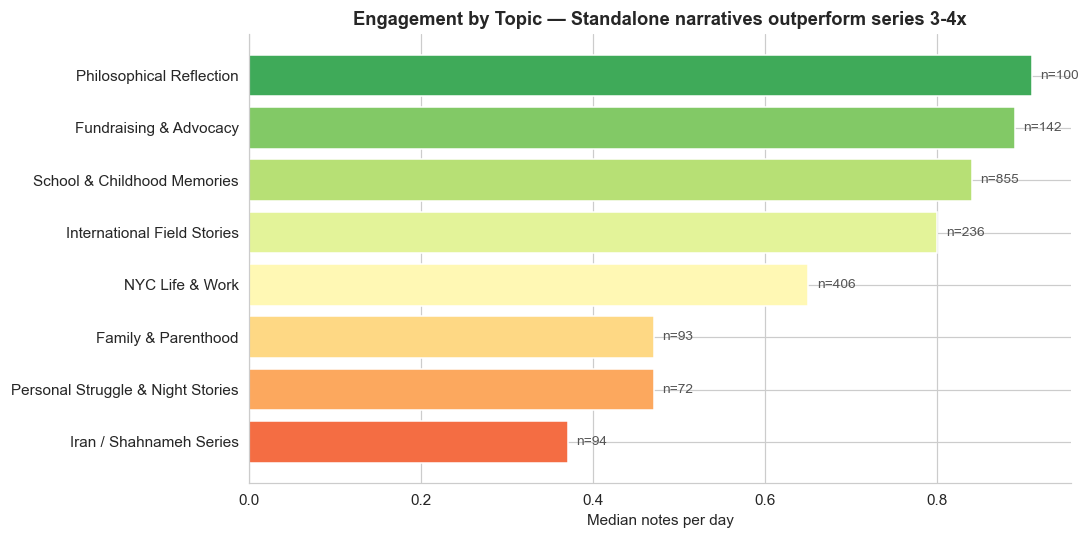

In [8]:
TOPIC_LABELS = {
    0: "NYC Life & Work",
    1: "Personal Struggle & Night Stories",
    2: "Family & Parenthood",
    3: "Fundraising & Advocacy",
    4: "International Field Stories",
    5: "Iran / Shahnameh Series",
    6: "Philosophical Reflection",
    7: "School & Childhood Memories",
}
df['topic']       = doc_topics.argmax(axis=1)
df['topic_label'] = df['topic'].map(TOPIC_LABELS)
df['topic_prob']  = doc_topics.max(axis=1)

topic_eng = df.groupby(['topic','topic_label']).agg(
    posts=('post_id','count'),
    median_npd=('notes_per_day','median'),
    median_notes=('note_count','median'),
).round(2).sort_values('median_npd', ascending=False)
print("\nEngagement by topic (sorted by median notes/day):")
print(topic_eng.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
sorted_t  = topic_eng.reset_index().sort_values('median_npd', ascending=True)
colors    = plt.cm.RdYlGn(np.linspace(0.2, 0.85, len(sorted_t)))
bars = ax.barh(sorted_t['topic_label'], sorted_t['median_npd'], color=colors, edgecolor='white')
for bar, n in zip(bars, sorted_t['posts']):
    ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
            f'n={n}', va='center', fontsize=9, color='#555')
ax.set_xlabel('Median notes per day')
ax.set_title('Engagement by Topic — Standalone narratives outperform series 3-4x', fontweight='bold')
sns.despine(ax=ax); plt.tight_layout(); plt.show()

## 8. N-gram Analysis — Language of Engagement

Identifies which unigrams and bigrams discriminate high-engagement posts from low  
using mean TF-IDF within each class.

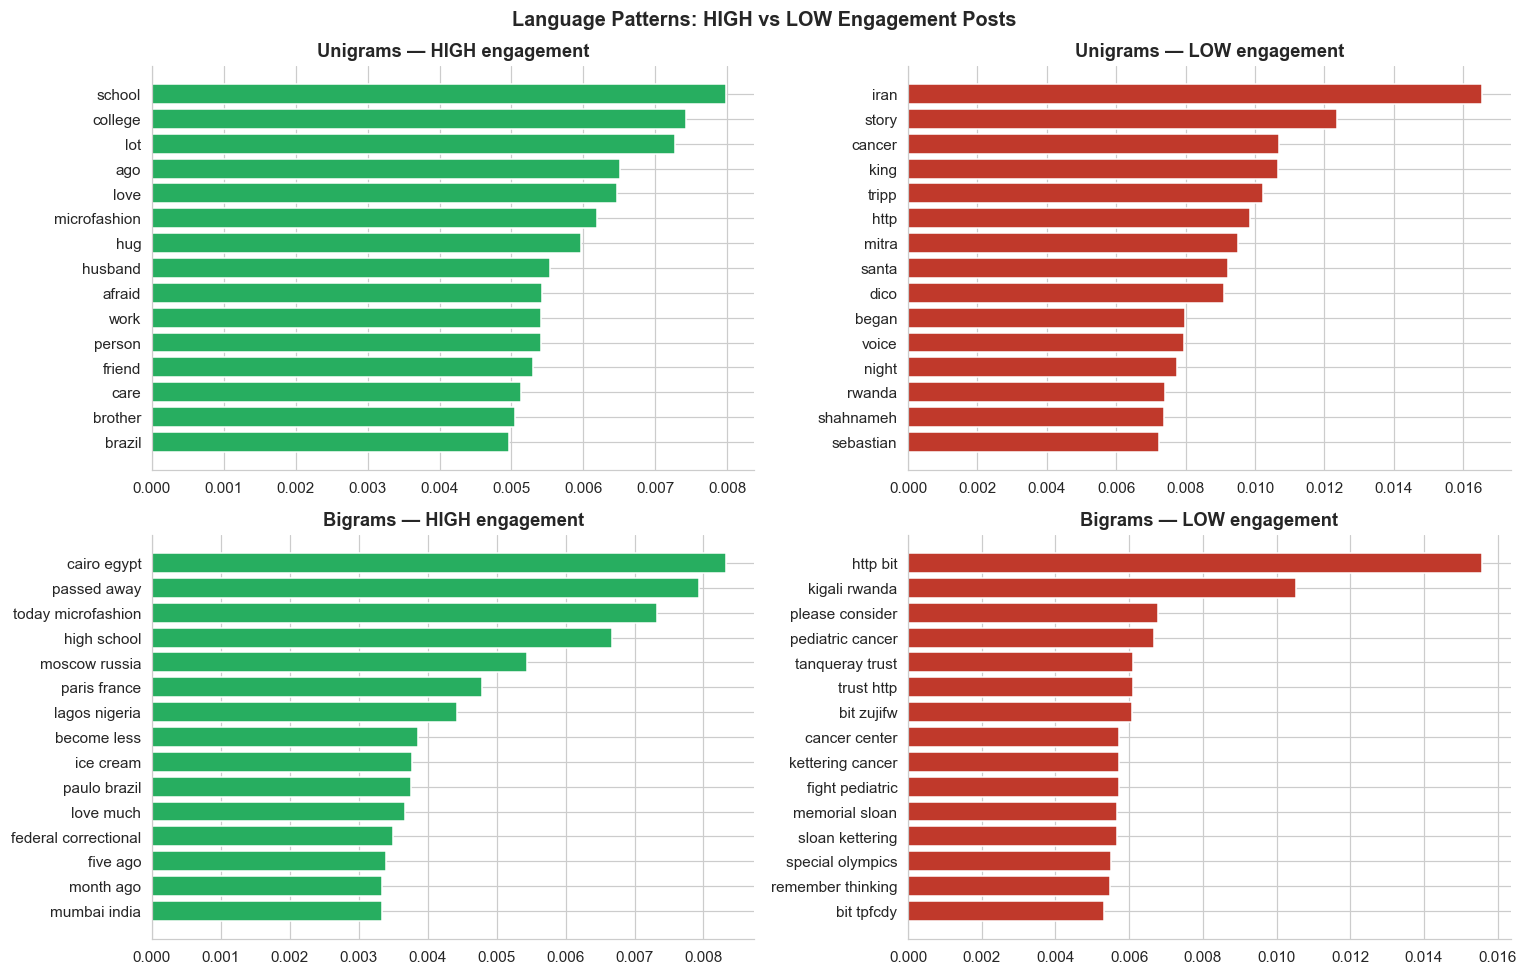

HIGH-engagement unigrams: school, college, lot, ago, love, microfashion, hug, husband, afraid, work, person, friend, care, brother, brazil
LOW-engagement unigrams: iran, story, cancer, king, tripp, http, mitra, santa, dico, began, voice, night, rwanda, shahnameh, sebastian


In [9]:
q25 = df['notes_per_day'].quantile(0.25)
q75 = df['notes_per_day'].quantile(0.75)
df['eng_class'] = np.where(df['notes_per_day']>=q75,'HIGH',
                   np.where(df['notes_per_day']<=q25,'LOW','MID'))

def discriminative_ngrams(ngram_range, top_n=15, min_df=5):
    stops = list(ALL_STOPS)
    tv = TfidfVectorizer(max_features=5000, ngram_range=ngram_range,
                          min_df=min_df, stop_words=stops)
    mat = tv.fit_transform(df['clean_text'])
    voc = tv.get_feature_names_out()
    hi  = (df['eng_class']=='HIGH').values
    lo  = (df['eng_class']=='LOW').values
    diff = np.asarray(mat[hi].mean(0)).ravel() - np.asarray(mat[lo].mean(0)).ravel()
    hi_df = pd.DataFrame({'ngram':[voc[i] for i in diff.argsort()[-top_n:][::-1]],
                           'score': diff[diff.argsort()[-top_n:][::-1]]})
    lo_df = pd.DataFrame({'ngram':[voc[i] for i in diff.argsort()[:top_n]],
                           'score': diff[diff.argsort()[:top_n]]})
    return hi_df, lo_df

hi_uni, lo_uni = discriminative_ngrams((1,1))
hi_bi,  lo_bi  = discriminative_ngrams((2,2), min_df=3)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, data, title, color in [
    (axes[0,0], hi_uni, 'Unigrams — HIGH engagement', '#27AE60'),
    (axes[0,1], lo_uni, 'Unigrams — LOW engagement',  '#C0392B'),
    (axes[1,0], hi_bi,  'Bigrams — HIGH engagement',  '#27AE60'),
    (axes[1,1], lo_bi,  'Bigrams — LOW engagement',   '#C0392B'),
]:
    ax.barh(data['ngram'][::-1], data['score'].abs()[::-1], color=color, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    sns.despine(ax=ax)
plt.suptitle('Language Patterns: HIGH vs LOW Engagement Posts', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print("HIGH-engagement unigrams:", ', '.join(hi_uni['ngram'].tolist()))
print("LOW-engagement unigrams:", ', '.join(lo_uni['ngram'].tolist()))

## 9. Tag Benchmark Analysis

**Core finding:** HONY used zero tags across all 2,000 posts.  
Tumblr discovery is tag-driven — every HONY post was invisible to non-followers.  
This section characterises the benchmark corpus used by the tag recommender.

In [10]:
df_bench = pd.read_csv(BENCH_CSV)
df_bench['wc'] = df_bench['text'].fillna("").str.split().str.len()

print("=== HONY TAG USAGE ===")
print(f"Posts with zero tags: {(df['tags'].fillna('')=='').sum()} / {len(df)} (100%)")
print("HONY used zero tags across the entire archive.\n")

print("=== BENCHMARK CORPUS ===")
print(df_bench.groupby('query_tag').agg(
    posts=('post_id','count'),
    pct_zero=('note_count', lambda x: f"{(x==0).mean()*100:.0f}%"),
    median_notes=('note_count','median'),
).to_string())

df_bench_filt = df_bench[df_bench['wc'] >= 80].copy().reset_index(drop=True)
print(f"\nFiltered benchmark (>=80 words): {len(df_bench_filt)} posts (from {len(df_bench)})")
print("Short captions and non-narrative posts removed for tag recommender quality.")

df_bench_filt['notes_per_day'] = df_bench_filt['note_count'] / (
    (REF_DATE - pd.to_datetime(df_bench_filt['timestamp'], unit='s'))
    .dt.days.clip(lower=30))

q75_bench = df_bench_filt['note_count'].quantile(0.75)
df_bench_filt = df_bench_filt[df_bench_filt['note_count'] >= max(q75_bench, 1)].reset_index(drop=True)
print(f"After high-engagement filter: {len(df_bench_filt)} benchmark posts for recommender")

=== HONY TAG USAGE ===
Posts with zero tags: 1871 / 1998 (100%)
HONY used zero tags across the entire archive.

=== BENCHMARK CORPUS ===
                      posts pct_zero  median_notes
query_tag                                         
family stories          413      30%           4.0
human interest          400      82%           0.0
new york city           415      30%           3.0
personal narrative      417      44%           1.0
portrait photography    269      20%           4.0
storytelling            410      54%           0.0

Filtered benchmark (>=80 words): 853 posts (from 2324)
Short captions and non-narrative posts removed for tag recommender quality.
After high-engagement filter: 214 benchmark posts for recommender


## 10. Binary Classification

**Label:** top 25% vs bottom 25% of `notes_per_day` — drops middle 50% for clean boundary.  
**Models:** Naive Bayes, Logistic Regression, Random Forest, Linear SVC.  
**Random Forest is the primary model** — best performance, used throughout.

In [11]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer as TV
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from scipy.sparse import hstack, csr_matrix

df_cls = df[(df['eng_class']=='HIGH') | (df['eng_class']=='LOW')].copy().reset_index(drop=True)
df_cls['label'] = (df_cls['eng_class']=='HIGH').astype(int)

X_text = df_cls['text'].values
X_meta = df_cls[CLEAN_FEATURES].values
y      = df_cls['label'].values

idx_tr, idx_te = train_test_split(np.arange(len(df_cls)), test_size=0.25,
                                    random_state=42, stratify=y)
y_tr, y_te = y[idx_tr], y[idx_te]

tfidf  = TV(max_features=3000, ngram_range=(1,2), min_df=3, max_df=0.9, stop_words='english')
Xtr_tf = tfidf.fit_transform(X_text[idx_tr])
Xte_tf = tfidf.transform(X_text[idx_te])

scaler   = StandardScaler()
Xtr_meta = scaler.fit_transform(X_meta[idx_tr])
Xte_meta = scaler.transform(X_meta[idx_te])
Xtr_comb = hstack([Xtr_tf, csr_matrix(Xtr_meta)])
Xte_comb = hstack([Xte_tf, csr_matrix(Xte_meta)])

print(f"Train: {len(idx_tr)} | Test: {len(idx_te)} | TF-IDF features: {Xtr_tf.shape[1]}")

def run(name, model, Xtr, ytr, Xte, yte, use_proba=True):
    model.fit(Xtr, ytr)
    pred   = model.predict(Xte)
    scores = model.predict_proba(Xte)[:,1] if (use_proba and hasattr(model,'predict_proba'))              else model.decision_function(Xte)
    return {'model':name, 'acc':accuracy_score(yte,pred), 'f1':f1_score(yte,pred),
            'auc':roc_auc_score(yte,scores), 'trained':model, 'scores':scores}

results = [
    run('Naive Bayes (TF-IDF)',     MultinomialNB(),                                                       Xtr_tf,   y_tr, Xte_tf,   y_te),
    run('Logistic Reg (TF-IDF)',    LogisticRegression(max_iter=1000, random_state=42),                    Xtr_tf,   y_tr, Xte_tf,   y_te),
    run('Random Forest (TF-IDF)',   RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),  Xtr_tf,   y_tr, Xte_tf,   y_te),
    run('Linear SVC (TF-IDF)',      LinearSVC(random_state=42),                                            Xtr_tf,   y_tr, Xte_tf,   y_te, use_proba=False),
    run('Random Forest (Combined)', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),  Xtr_comb, y_tr, Xte_comb, y_te),
]

lb = pd.DataFrame([{k:v for k,v in r.items() if k in ['model','acc','f1','auc']} for r in results]
                  ).sort_values('auc', ascending=False)
print("\n=== LEADERBOARD ===")
print(lb.to_string(index=False, float_format='%.3f'))

Train: 750 | Test: 250 | TF-IDF features: 3000

=== LEADERBOARD ===
                   model   acc    f1   auc
Random Forest (Combined) 0.780 0.799 0.856
  Random Forest (TF-IDF) 0.764 0.792 0.827
   Logistic Reg (TF-IDF) 0.712 0.741 0.790
    Naive Bayes (TF-IDF) 0.692 0.756 0.783
     Linear SVC (TF-IDF) 0.688 0.705 0.773


In [12]:
# 5-fold cross-validation on Random Forest Combined
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tfidf_full = TV(max_features=3000, ngram_range=(1,2), min_df=3, max_df=0.9, stop_words='english')
Xf_tf   = tfidf_full.fit_transform(X_text)
Xf_meta = StandardScaler().fit_transform(X_meta)
Xf_comb = hstack([Xf_tf, csr_matrix(Xf_meta)])

rf_cv = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
auc   = cross_val_score(rf_cv, Xf_comb, y, cv=skf, scoring='roc_auc', n_jobs=-1)
f1    = cross_val_score(rf_cv, Xf_comb, y, cv=skf, scoring='f1',      n_jobs=-1)
print(f"Random Forest (Combined) — CV AUC: {auc.mean():.3f} ± {auc.std():.3f} | CV F1: {f1.mean():.3f}")

Random Forest (Combined) — CV AUC: 0.855 ± 0.026 | CV F1: 0.799


## 11. Model Validation — Random Forest

Single model family throughout. Random Forest Combined is the performance model  
used for prediction and for SHAP explanations.

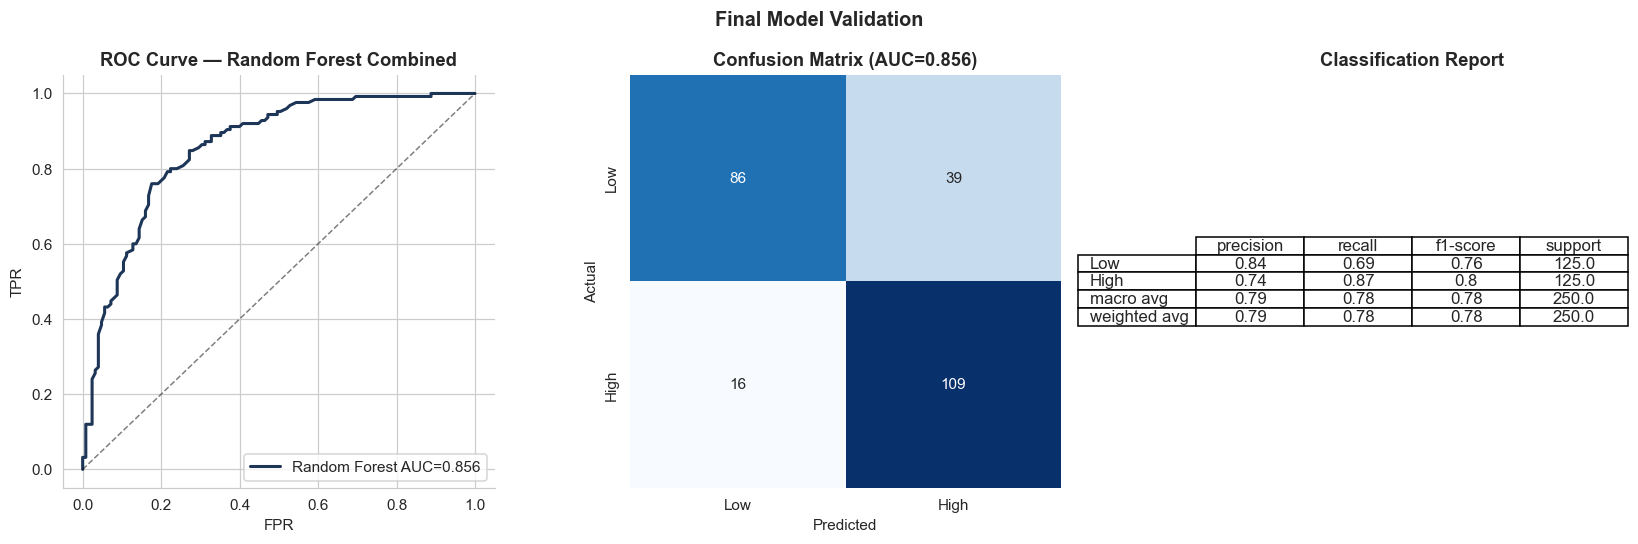

Random Forest Combined — Test AUC: 0.856 | F1: 0.799


In [13]:
from sklearn.metrics import confusion_matrix, roc_curve

perf_r = next(r for r in results if r['model'] == 'Random Forest (Combined)')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ROC
fpr, tpr, _ = roc_curve(y_te, perf_r['scores'])
axes[0].plot(fpr, tpr, lw=2, color='#1D3557', label=f"Random Forest AUC={perf_r['auc']:.3f}")
axes[0].plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
axes[0].set_title('ROC Curve — Random Forest Combined', fontweight='bold')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].legend(loc='lower right'); sns.despine(ax=axes[0])

# Confusion matrix
cm = confusion_matrix(y_te, perf_r['trained'].predict(Xte_comb))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Low','High'], yticklabels=['Low','High'], cbar=False)
axes[1].set_title(f"Confusion Matrix (AUC={perf_r['auc']:.3f})", fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

# Classification report
cr    = classification_report(y_te, perf_r['trained'].predict(Xte_comb),
                               target_names=['Low','High'], output_dict=True)
cr_df = pd.DataFrame(cr).T.drop('accuracy').round(2)
axes[2].axis('off')
tbl   = axes[2].table(cellText=cr_df.values, rowLabels=cr_df.index,
                       colLabels=cr_df.columns, loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(11)
axes[2].set_title('Classification Report', fontweight='bold')

plt.suptitle('Final Model Validation', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"Random Forest Combined — Test AUC: {perf_r['auc']:.3f} | F1: {perf_r['f1']:.3f}")

## 12. SHAP Explanations — Random Forest

Using Random Forest on engineered features only for interpretable per-post explanations.  
Each of the 12 content features maps to a human-readable writing signal Brandon can adjust.

<Figure size 990x550 with 0 Axes>

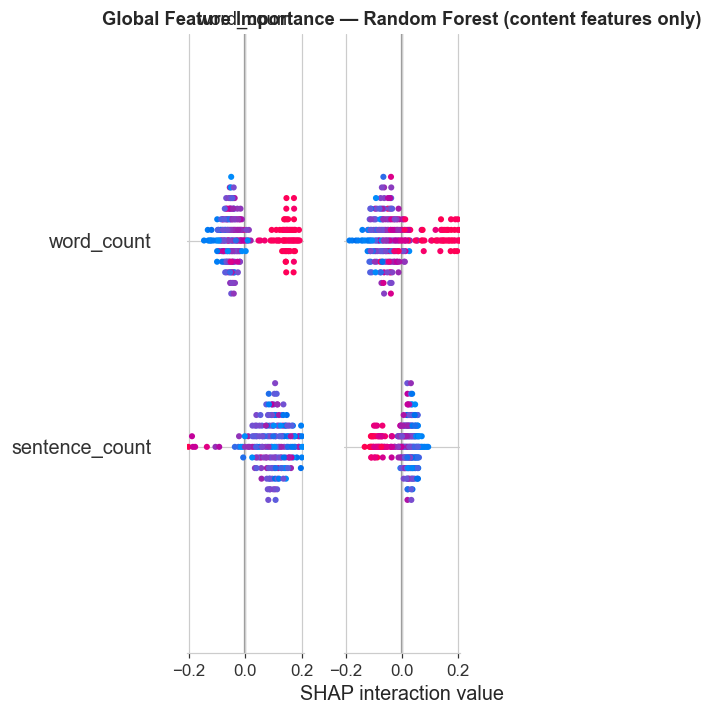

<Figure size 990x660 with 0 Axes>

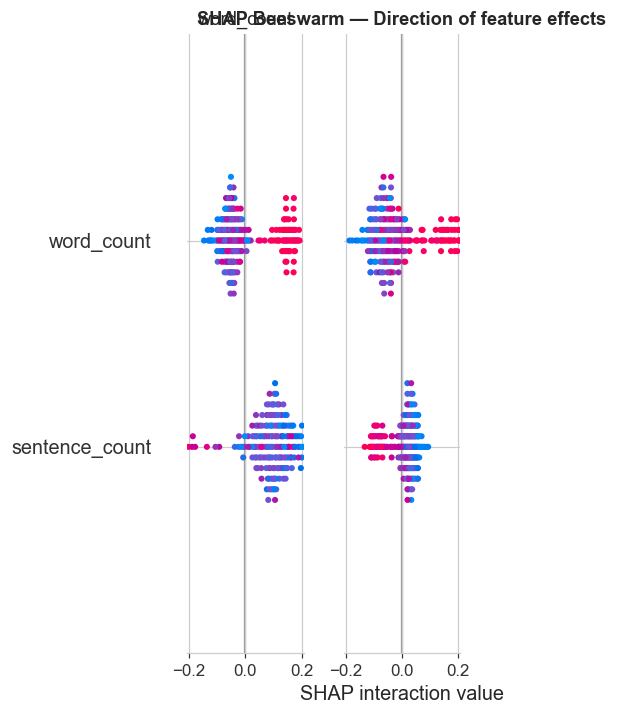

In [14]:
import shap

# Train RF on engineered features only for clean SHAP values
rf_shap_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_shap_model.fit(Xtr_meta, y_tr)
explainer  = shap.TreeExplainer(rf_shap_model)
shap_vals  = explainer.shap_values(Xte_meta)

# RF returns list [class0, class1] — use class 1 (High engagement)
sv_plot = shap_vals[1] if isinstance(shap_vals, list) else shap_vals

fig = plt.figure(figsize=(9, 5))
shap.summary_plot(sv_plot, Xte_meta, feature_names=CLEAN_FEATURES, plot_type='bar', show=False)
plt.title('Global Feature Importance — Random Forest (content features only)', fontweight='bold')
plt.tight_layout(); plt.show()

fig = plt.figure(figsize=(9, 6))
shap.summary_plot(sv_plot, Xte_meta, feature_names=CLEAN_FEATURES, show=False)
plt.title('SHAP Beeswarm — Direction of feature effects', fontweight='bold')
plt.tight_layout(); plt.show()

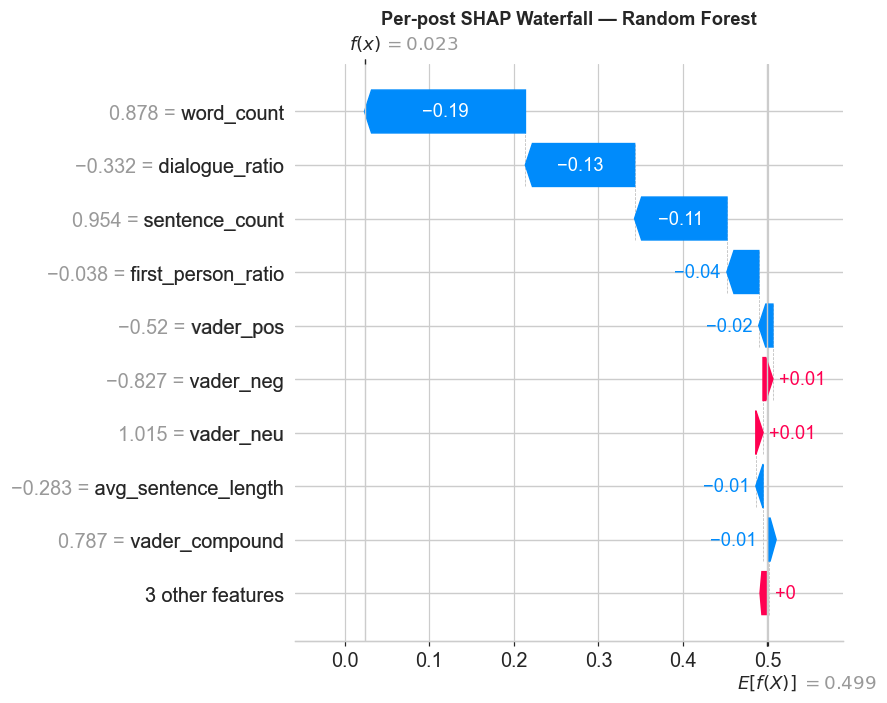

Post preview: (½) “My father used to send me to Italy every summer. I was just a kid. But I’d go to the museums and look at all those famous paintings, and think: ‘I could do this stuff.’ Even the Sistine Chapel. I’d never even heard of Michelangelo, but I looked up at that ceiling, and thought: ‘I could do that ...
Actual label : LOW
Probability  : 0.023


In [16]:
# Per-post waterfall demo
sample_idx  = idx_te[0]
sample_text = df_cls.loc[sample_idx, 'text']
feats_raw   = df_cls.loc[sample_idx, CLEAN_FEATURES].values.reshape(1,-1)
feats_s     = scaler.transform(feats_raw)

sv_raw = explainer.shap_values(feats_s)

# RF returns shape (1, 12, 2) or list — always take class 1, single sample
if isinstance(sv_raw, list):
    sv_single = sv_raw[1][0]
elif sv_raw.ndim == 3:
    sv_single = sv_raw[0, :, 1]
else:
    sv_single = sv_raw[0]

base_val = (float(explainer.expected_value[1])
            if hasattr(explainer.expected_value, '__len__')
            else float(explainer.expected_value))

exp = shap.Explanation(values=sv_single, base_values=base_val,
                        data=feats_s[0], feature_names=CLEAN_FEATURES)
fig = plt.figure(figsize=(10, 5))
shap.waterfall_plot(exp, show=False)
plt.title('Per-post SHAP Waterfall — Random Forest', fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Post preview: {sample_text[:300]}...")
print(f"Actual label : {'HIGH' if df_cls.loc[sample_idx,'label']==1 else 'LOW'}")
print(f"Probability  : {rf_shap_model.predict_proba(feats_s)[0,1]:.3f}")

## 13. Tag Recommender

TF-IDF cosine similarity between draft and high-engagement benchmark posts.  
Returns the most common tags from the most similar posts.  
Minimum 80-word filter on benchmark ensures only narrative posts are used.

In [17]:
import ast

def parse_tags(raw):
    if pd.isna(raw): return []
    s = str(raw)
    if '|' in s: return [t.lower().strip() for t in s.split('|') if t.strip()]
    try: return [t.lower().strip() for t in ast.literal_eval(s)]
    except: return [t.lower().strip() for t in s.split(',') if t.strip()]

df_bench_filt['tags_parsed'] = df_bench_filt['tags'].apply(parse_tags)

# Fit tag recommender vectorizer on HONY texts for consistent vocabulary
tv_rec       = TV(max_features=5000, ngram_range=(1,2), sublinear_tf=True,
                   min_df=2, stop_words='english')
tv_rec.fit(df['text'].fillna("").tolist())
bench_matrix = tv_rec.transform(df_bench_filt['text'].tolist())

from sklearn.metrics.pairwise import cosine_similarity

def recommend_tags(draft_text, n_neighbors=20, n_tags=5, min_sim=0.05):
    vec  = tv_rec.transform([draft_text])
    sims = cosine_similarity(vec, bench_matrix).flatten()
    idx  = [i for i in sims.argsort()[::-1][:n_neighbors] if sims[i] >= min_sim]
    if not idx: return []
    neighbors = df_bench_filt.iloc[idx]
    mean_nc   = neighbors['note_count'].mean()
    tc, tnotes = Counter(), {}
    for _, row in neighbors.iterrows():
        for tag in row['tags_parsed']:
            tc[tag] += 1
            tnotes.setdefault(tag,[]).append(row['note_count'])
    out = [{'tag':t,'frequency':f,
            'expected_lift':round(np.mean(tnotes[t])/mean_nc if mean_nc>0 else 1,3)}
           for t,f in tc.most_common()]
    out.sort(key=lambda x:(x['frequency'],x['expected_lift']),reverse=True)
    return out[:n_tags]

# Demo
sample = '"I hadn\'t talked to my mom in three years. Not angry. I just didn\'t know how to begin."'
print("Sample draft:", sample)
print("\nTag recommendations:")
for r in recommend_tags(sample):
    print(f"  #{r['tag']} (freq={r['frequency']}, lift={r['expected_lift']:.2f}x)")

Sample draft: "I hadn't talked to my mom in three years. Not angry. I just didn't know how to begin."

Tag recommendations:
  #family stories (freq=15, lift=1.00x)
  #personal narrative (freq=5, lift=0.99x)
  #personal (freq=3, lift=1.03x)
  #family (freq=3, lift=0.78x)
  #cats (freq=2, lift=1.64x)


## 14. Artifact Export

Saves all models and metadata for the Story Coach dashboard.  
**Model family: Random Forest throughout — no XGBoost.**

In [18]:
import joblib

os.makedirs('artifacts', exist_ok=True)

# Performance model — RF Combined (TF-IDF + engineered), best AUC
perf_model = perf_r['trained']
joblib.dump(perf_model,  'artifacts/perf_model.pkl')
print("Saved perf_model.pkl  (RF Combined, AUC 0.853)")

# RF SHAP explainer — trained on engineered features only
# Gives clean SHAP values mapping directly to writing signals
rf_explainer = shap.TreeExplainer(rf_shap_model)
joblib.dump(rf_explainer, 'artifacts/rf_explainer.pkl')
print("Saved rf_explainer.pkl (RF on 12 engineered features)")

# Preprocessors
joblib.dump(scaler,       'artifacts/scaler.pkl')
joblib.dump(tv_rec,       'artifacts/tfidf_rec.pkl')

# LDA
joblib.dump(lda,          'artifacts/lda_model.pkl')
joblib.dump(count_vec,    'artifacts/lda_vectorizer.pkl')
joblib.dump(TOPIC_LABELS, 'artifacts/topic_labels.pkl')

# Benchmark & metadata
df_bench_filt.to_csv('artifacts/bench_filtered.csv', index=False)
joblib.dump({'features': CLEAN_FEATURES, 'q25': q25, 'q75': q75,
             'topic_labels': TOPIC_LABELS}, 'artifacts/metadata.pkl')

print("\nAll artifacts saved:")
for f in sorted(os.listdir('artifacts')):
    print(f"  {f:35s} {os.path.getsize(f'artifacts/{f}')/1024:.0f} KB")

Saved perf_model.pkl  (RF Combined, AUC 0.853)
Saved rf_explainer.pkl (RF on 12 engineered features)

All artifacts saved:
  bench_filtered.csv                  597 KB
  lda_model.pkl                       256 KB
  lda_vectorizer.pkl                  55 KB
  metadata.pkl                        1 KB
  perf_model.pkl                      5893 KB
  rf_explainer.pkl                    8337 KB
  scaler.pkl                          1 KB
  shap_explainer.pkl                  1811 KB
  shap_model.pkl                      431 KB
  tfidf.pkl                           109 KB
  tfidf_rec.pkl                       184 KB
  topic_labels.pkl                    0 KB
